<a href="https://colab.research.google.com/github/TramSt/decision-tree-pima-diabetes/blob/main/notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Import Thư viện

In [1]:
import pandas as pd
import numpy as np

In [2]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [10]:

!rm -rf decision-tree-pima-diabetes
!git clone https://github.com/TramSt/decision-tree-pima-diabetes.git
%cd decision-tree-pima-diabetes
!ls


Cloning into 'decision-tree-pima-diabetes'...
remote: Enumerating objects: 89, done.
remote: Counting objects: 100% (89/89), done.
remote: Compressing objects: 100% (78/78), done.
remote: Total 89 (delta 33), reused 3 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (89/89), 433.68 KiB | 3.08 MiB/s, done.
Resolving deltas: 100% (33/33), done.
/content/decision-tree-pima-diabetes/decision-tree-pima-diabetes
data  notebooks  README.md  slides


In [11]:
!ls data

diabetes.csv


# 2. Read data EDA

In [12]:
df = pd.read_csv("../data/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [13]:
df = pd.read_csv("data/diabetes.csv")
df.head()



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [14]:
print(f'Bộ dữ liệu có {df.shape[0]} dòng và {df.shape[1]} cột')


Bộ dữ liệu có 768 dòng và 9 cột


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [16]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [17]:
(df == 0).sum()
# Glucose, BloodPressure, BMI có giá trị = 0 là không hợp lý về mặt y học
# → xem như missing values
# → cần xử lý ở bước preprocessing

,0
Pregnancies,111
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,500


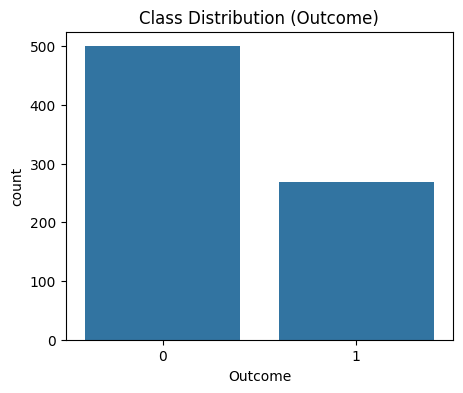

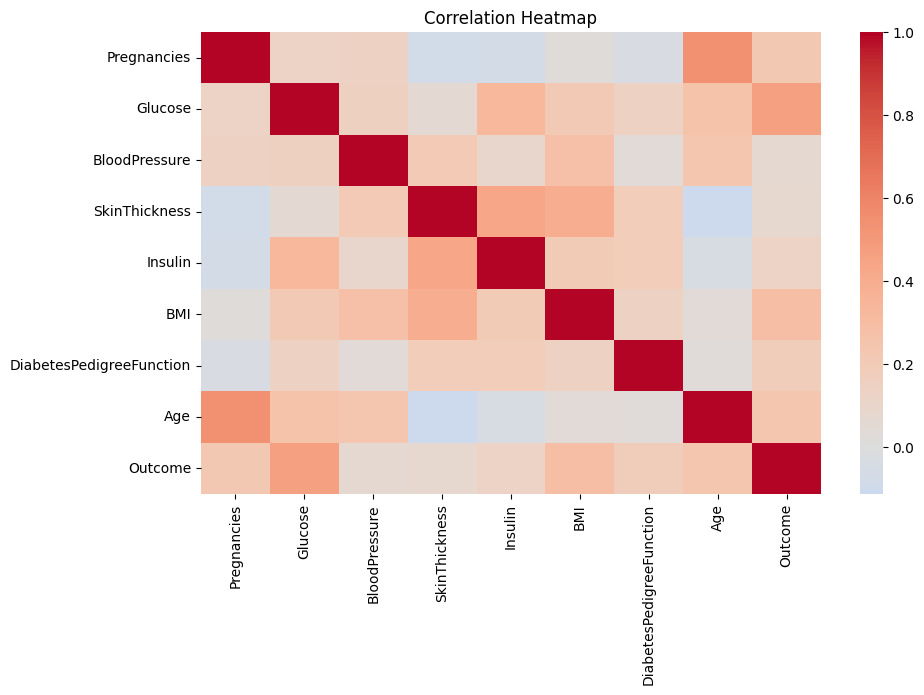

In [18]:
plt.figure(figsize=(5,4))
sns.countplot(x="Outcome", data=df)
plt.title("Class Distribution (Outcome)")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [19]:
#missing value
df_clean = df.copy()

invalid_zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df_clean[invalid_zero_cols] = df_clean[invalid_zero_cols].replace(0, np.nan)

df_clean[invalid_zero_cols].isna().sum()

,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


In [20]:
#Train/Test split
X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(614, 8) (154, 8)


In [21]:
#Pipeline preprocessing (imputer + scaler)
preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


In [22]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

def evaluate_model(model, X_test, y_test, title="Model"): #ham danh gia
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else None

    print("===", title, "===")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1-score :", f1_score(y_test, y_pred))
    if y_prob is not None:
        print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

    print("\nClassification report:\n", classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {title}")
    plt.show()

    if y_prob is not None:
        RocCurveDisplay.from_predictions(y_test, y_prob)
        plt.title(f"ROC Curve - {title}")
        plt.show()

=== Logistic Regression (baseline) ===
Accuracy : 0.7077922077922078
Precision: 0.6
Recall   : 0.5
F1-score : 0.5454545454545454
ROC-AUC  : 0.812962962962963

Classification report:
               precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



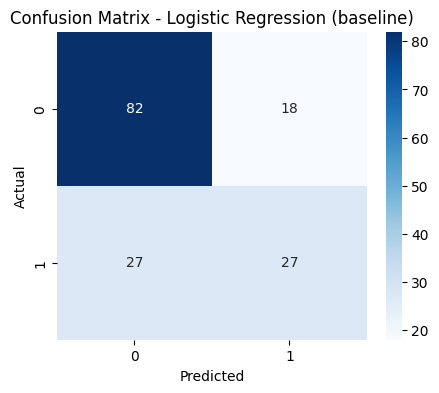

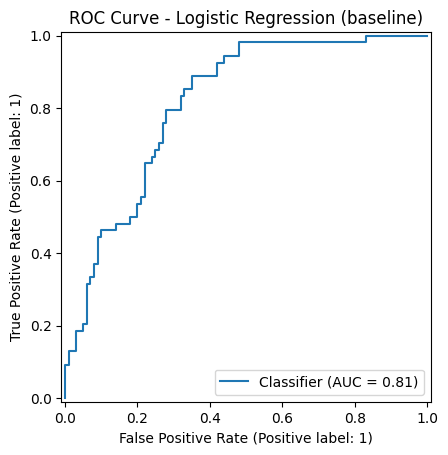

In [23]:
logreg = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000))
])

logreg.fit(X_train, y_train)
evaluate_model(logreg, X_test, y_test, "Logistic Regression (baseline)")


- ROC curve biểu diễn mối quan hệ giữa TPR và FPR khi thay đổi threshold.
- Đường cong càng gần góc trên trái thì model càng tốt.
- AUC = 0.81 cho thấy mô hình Logistic Regression có khả năng phân biệt hai lớp khá tốt.

=== Random Forest ===
Accuracy : 0.7532467532467533
Precision: 0.6739130434782609
Recall   : 0.5740740740740741
F1-score : 0.62
ROC-AUC  : 0.8202777777777777

Classification report:
               precision    recall  f1-score   support

           0       0.79      0.85      0.82       100
           1       0.67      0.57      0.62        54

    accuracy                           0.75       154
   macro avg       0.73      0.71      0.72       154
weighted avg       0.75      0.75      0.75       154



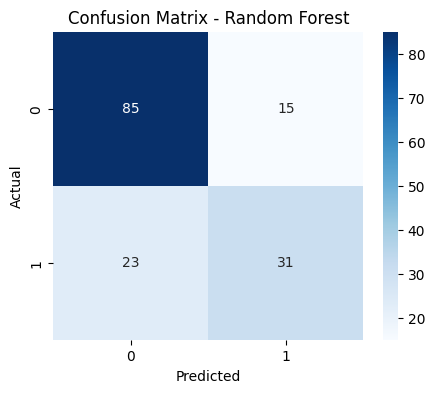

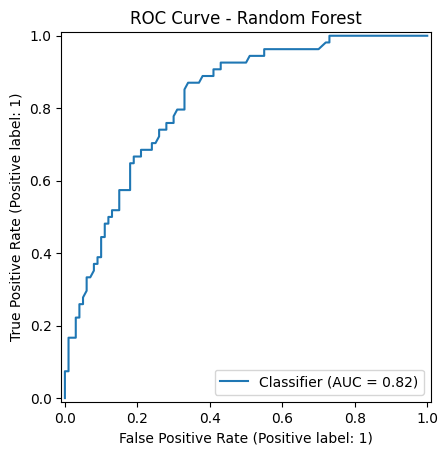

=== SVM (RBF) ===
Accuracy : 0.7272727272727273
Precision: 0.5909090909090909
Recall   : 0.7222222222222222
F1-score : 0.65
ROC-AUC  : 0.8138888888888889

Classification report:
               precision    recall  f1-score   support

           0       0.83      0.73      0.78       100
           1       0.59      0.72      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.71       154
weighted avg       0.75      0.73      0.73       154



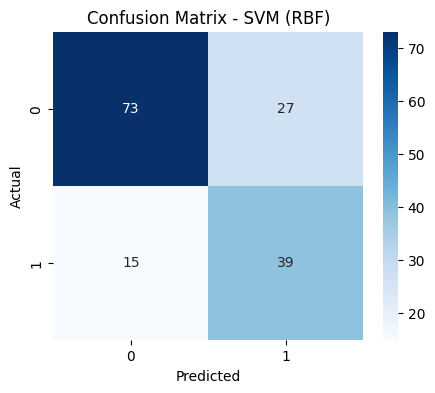

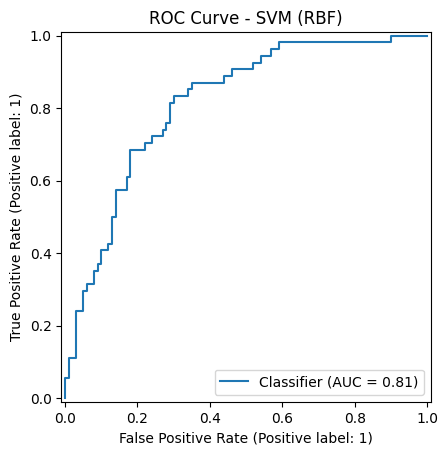

In [24]:
rf = Pipeline(steps=[
    ("preprocess", preprocess),   # RF không bắt buộc scale nhưng giữ pipeline đồng nhất
    ("model", RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        class_weight="balanced"  # giúp cải thiện recall khi lệch lớp
    ))
])

svm = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42))
])

rf.fit(X_train, y_train)
svm.fit(X_train, y_train)

evaluate_model(rf, X_test, y_test, "Random Forest")
evaluate_model(svm, X_test, y_test, "SVM (RBF)")

Biểu đồ ROC của Random Forest cho thấy đường cong nằm khá gần góc trên bên trái, thể hiện khả năng phân loại tốt giữa hai lớp. Với AUC = 0.82, mô hình đạt hiệu suất cao nhất trong ba mô hình được so sánh.

Ở vùng FPR thấp (0 → 0.2), đường cong tăng nhanh, nghĩa là mô hình có thể phát hiện được nhiều mẫu dương tính trong khi vẫn giữ tỷ lệ báo nhầm thấp. Điều này đặc biệt quan trọng trong các bài toán như chẩn đoán bệnh, nơi việc hạn chế false positive là cần thiết.

Tuy nhiên, từ vùng FPR trung bình trở đi, tốc độ tăng của TPR chậm lại, cho thấy để cải thiện thêm khả năng phát hiện, mô hình phải chấp nhận đánh đổi bằng việc tăng false positive.

Biểu đồ ROC của SVM với kernel RBF cũng cho thấy đường cong nằm trên đường chéo ngẫu nhiên, chứng tỏ mô hình có khả năng học được mối quan hệ phi tuyến trong dữ liệu. Với AUC = 0.81, hiệu suất của mô hình ở mức tốt, nhưng thấp hơn một chút so với Random Forest.

Ở vùng FPR thấp, đường cong tăng khá đều, tuy nhiên không đạt mức cao như Random Forest, cho thấy khả năng phát hiện đúng trong điều kiện hạn chế false positive chưa tối ưu bằng. Ở các vùng FPR cao hơn, đường cong dần tiệm cận TPR = 1, tương tự các mô hình khác.

Dựa trên ROC và AUC, Random Forest đạt hiệu suất cao nhất với AUC = 0.82, cho thấy khả năng phân biệt hai lớp tốt hơn một chút so với Logistic Regression và SVM (AUC = 0.81). Tuy nhiên, sự chênh lệch là nhỏ nên cần xem xét thêm các chỉ số khác trước khi kết luận.

In [25]:
def quick_scores(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

rows = [
    quick_scores(logreg, X_test, y_test, "LogReg"),
    quick_scores(rf, X_test, y_test, "RF"),
    quick_scores(svm, X_test, y_test, "SVM")
]
pd.DataFrame(rows).sort_values("ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
1,RF,0.753247,0.673913,0.574074,0.620000,0.820278
2,SVM,0.727273,0.590909,0.722222,0.650000,0.813889
0,LogReg,0.707792,0.600000,0.500000,0.545455,0.812963


Random Forest đạt AUC cao nhất (0.82), cho thấy khả năng phân loại tốt nhất trong các mô hình thử nghiệm. Tuy nhiên, sự khác biệt với Logistic Regression và SVM là không đáng kể. Xét đến tính đơn giản và khả năng giải thích, Logistic Regression vẫn là một lựa chọn phù hợp cho bài toán dự đoán tiểu đường trên bộ dữ liệu Pima.

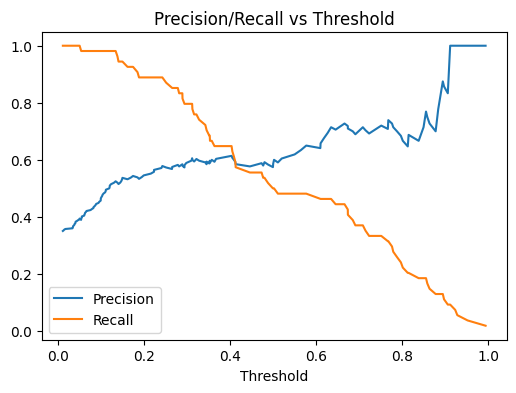

Chosen threshold: 0.28884726350364276
Recall: 0.8148148148148148
Precision: 0.5789473684210527
F1: 0.676923076923077


In [28]:
from sklearn.metrics import precision_recall_curve
best = logreg  # hoặc rf / svm tùy model tốt nhất
y_prob = best.predict_proba(X_test)[:,1]

prec, rec, thr = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(thr, prec[:-1], label="Precision")
plt.plot(thr, rec[:-1], label="Recall")
plt.xlabel("Threshold")
plt.legend()
plt.title("Precision/Recall vs Threshold")
plt.show()

# Ví dụ chọn threshold để Recall >= 0.80 (tùy mục tiêu)
target_recall = 0.80
idx = np.where(rec[:-1] >= target_recall)[0]
if len(idx) > 0:
    chosen_thr = thr[idx[-1]]
    print("Chosen threshold:", chosen_thr)
else:
    chosen_thr = 0.5
    print("Cannot reach target recall, fallback 0.5")

y_pred_thr = (y_prob >= chosen_thr).astype(int)
print("Recall:", recall_score(y_test, y_pred_thr))
print("Precision:", precision_score(y_test, y_pred_thr))
print("F1:", f1_score(y_test, y_pred_thr))


Biểu đồ Precision–Recall cho thấy sự đánh đổi rõ ràng giữa hai chỉ số khi thay đổi threshold. Ngưỡng 0.29 được lựa chọn giúp đạt Recall cao (0.81), phù hợp với bài toán y tế khi cần hạn chế bỏ sót ca bệnh, dù Precision chỉ ở mức trung bình. Điều này cho thấy mô hình ưu tiên phát hiện dương tính hơn là giảm thiểu kết quả dương tính giả (false positive).

Best params: {'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best CV ROC-AUC: 0.8429969545957918
=== Tuned Logistic Regression ===
Accuracy : 0.7077922077922078
Precision: 0.6
Recall   : 0.5
F1-score : 0.5454545454545454
ROC-AUC  : 0.812962962962963

Classification report:
               precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



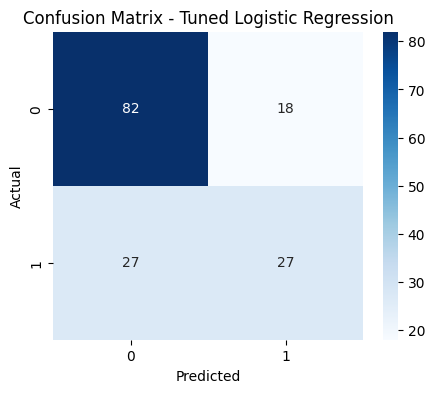

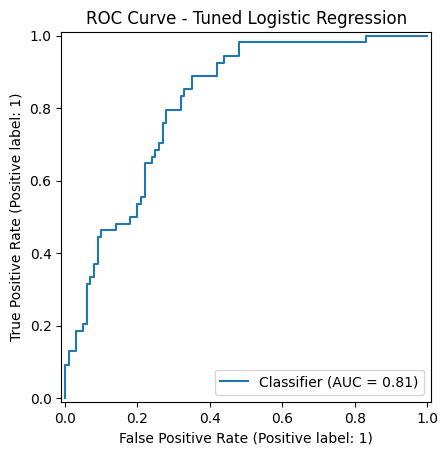

In [30]:
from sklearn.model_selection import GridSearchCV
pipe_lr = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=3000))
])

param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"]
}

grid = GridSearchCV(
    pipe_lr, param_grid=param_grid,
    scoring="roc_auc", cv=5, n_jobs=-1
)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)

best_lr = grid.best_estimator_
evaluate_model(best_lr, X_test, y_test, "Tuned Logistic Regression")

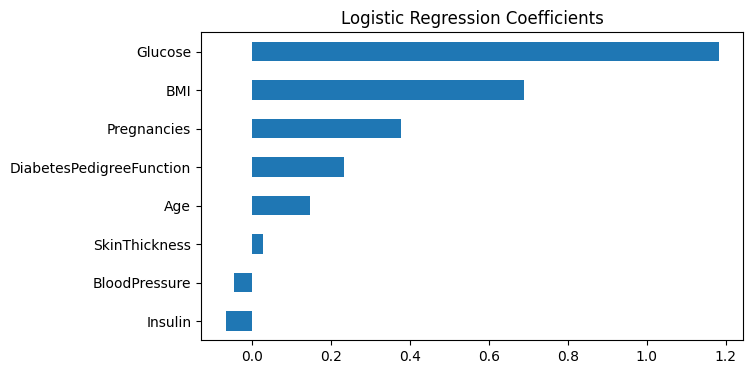

In [31]:
feature_names = X.columns
coef = best_lr.named_steps["model"].coef_[0]
imp_lr = pd.Series(coef, index=feature_names).sort_values()

plt.figure(figsize=(7,4))
imp_lr.plot(kind="barh")
plt.title("Logistic Regression Coefficients")
plt.show()